In [2]:
import pandas as pd
import numpy as np

# Random seed for reproducibility
np.random.seed(42)

# Data size
n = 1000

# Generate random data
dates = pd.date_range(start='2025-01-01', periods=n, freq='D')
products = ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Monitor']
regions = ['North', 'South', 'East', 'West']

data = pd.DataFrame({
    'Date': np.random.choice(dates, n),
    'Product': np.random.choice(products, n),
    'Region': np.random.choice(regions, n),
    'Units_Sold': np.random.randint(1, 20, n),
    'Unit_Price': np.random.randint(50, 1000, n)
})

# Calculate Revenue
data['Revenue'] = data['Units_Sold'] * data['Unit_Price']

data.head()


,Date,Product,Region,Units_Sold,Unit_Price,Revenue
0,2025-04-13,Monitor,West,8,670,5360
1,2026-03-12,Monitor,West,10,904,9040
2,2027-05-11,Laptop,West,6,222,1332
3,2025-09-28,Laptop,South,15,798,11970
4,2025-04-17,Phone,South,16,211,3376


In [4]:
# Check for missing values
print(data.isnull().sum())


Date          0
Product       0
Region        0
Units_Sold    0
Unit_Price    0
Revenue       0
dtype: int64


In [6]:
# Check duplicates
print(data.duplicated().sum())


0


In [8]:
# Data types
print(data.dtypes)

Date          datetime64[ns]
Product               object
Region                object
Units_Sold             int32
Unit_Price             int32
Revenue                int32
dtype: object


In [ ]:
# Summary statistics
data.describe()

,Date,Units_Sold,Unit_Price,Revenue
count,1000,1000.000000,1000.000000,1000.000000
mean,2026-05-19 22:17:45.600000,10.117000,521.001000,5269.431000
min,2025-01-01 00:00:00,1.000000,50.000000,89.000000
25%,2025-08-31 18:00:00,5.000000,284.000000,1681.500000
50%,2026-05-21 00:00:00,10.000000,529.000000,4174.000000
75%,2027-01-28 06:00:00,15.000000,747.000000,7836.750000
max,2027-09-26 00:00:00,19.000000,999.000000,18867.000000
std,NaN,5.522845,271.634807,4256.064113


In [12]:
#Total revenue by product
product_sales = data.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print(product_sales)

Product
Tablet        1112471
Laptop        1097213
Monitor       1071008
Phone         1058076
Headphones     930663
Name: Revenue, dtype: int32


<Axes: title={'center': 'Daily Revenue Trend'}, xlabel='Date'>

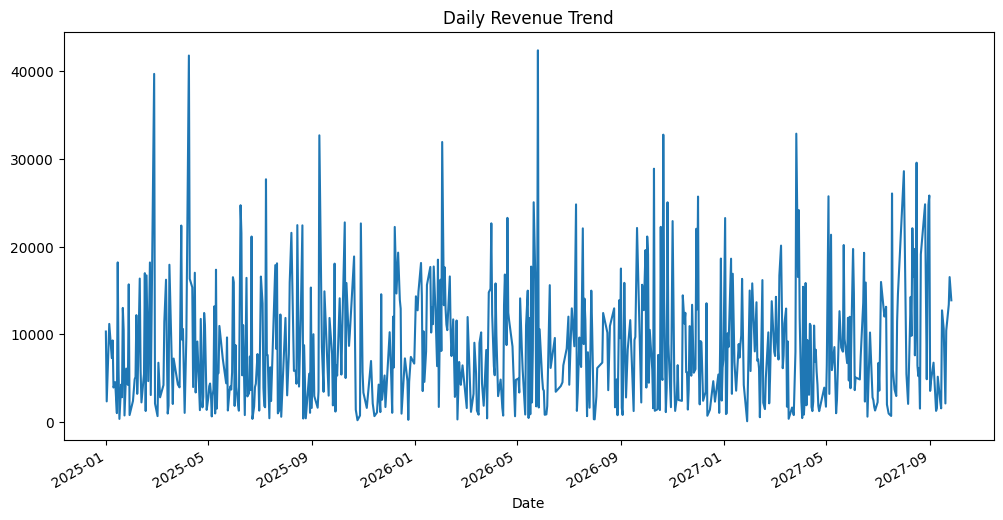

In [14]:
# Revenue trend over time
daily_revenue = data.groupby('Date')['Revenue'].sum()
daily_revenue.plot(figsize=(12,6), title="Daily Revenue Trend")


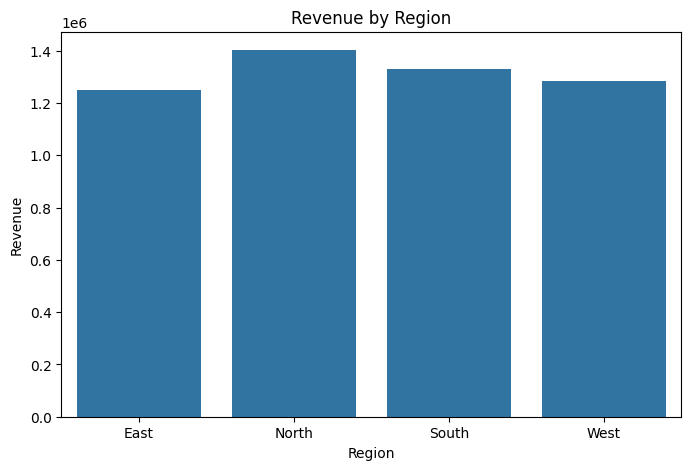

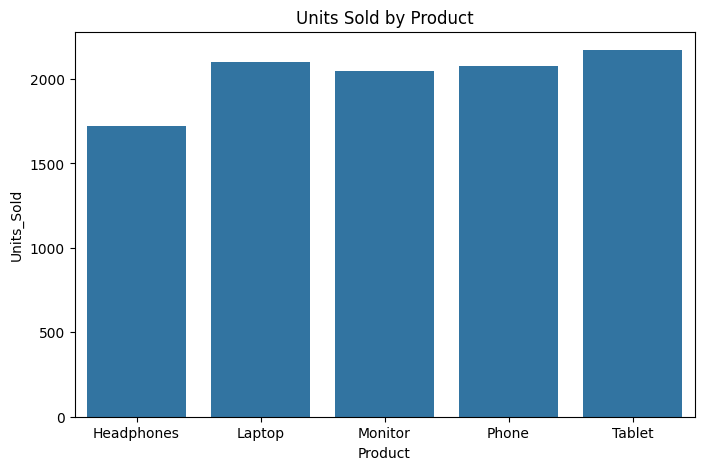

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue by Region
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Revenue', data=data.groupby('Region')['Revenue'].sum().reset_index())
plt.title('Revenue by Region')
plt.show()

# Units sold by product
plt.figure(figsize=(8,5))
sns.barplot(x='Product', y='Units_Sold', data=data.groupby('Product')['Units_Sold'].sum().reset_index())
plt.title('Units Sold by Product')
plt.show()
